<a href="https://colab.research.google.com/github/sjhallo07/Quantum_Relativistic_Engine/blob/main/deeptest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

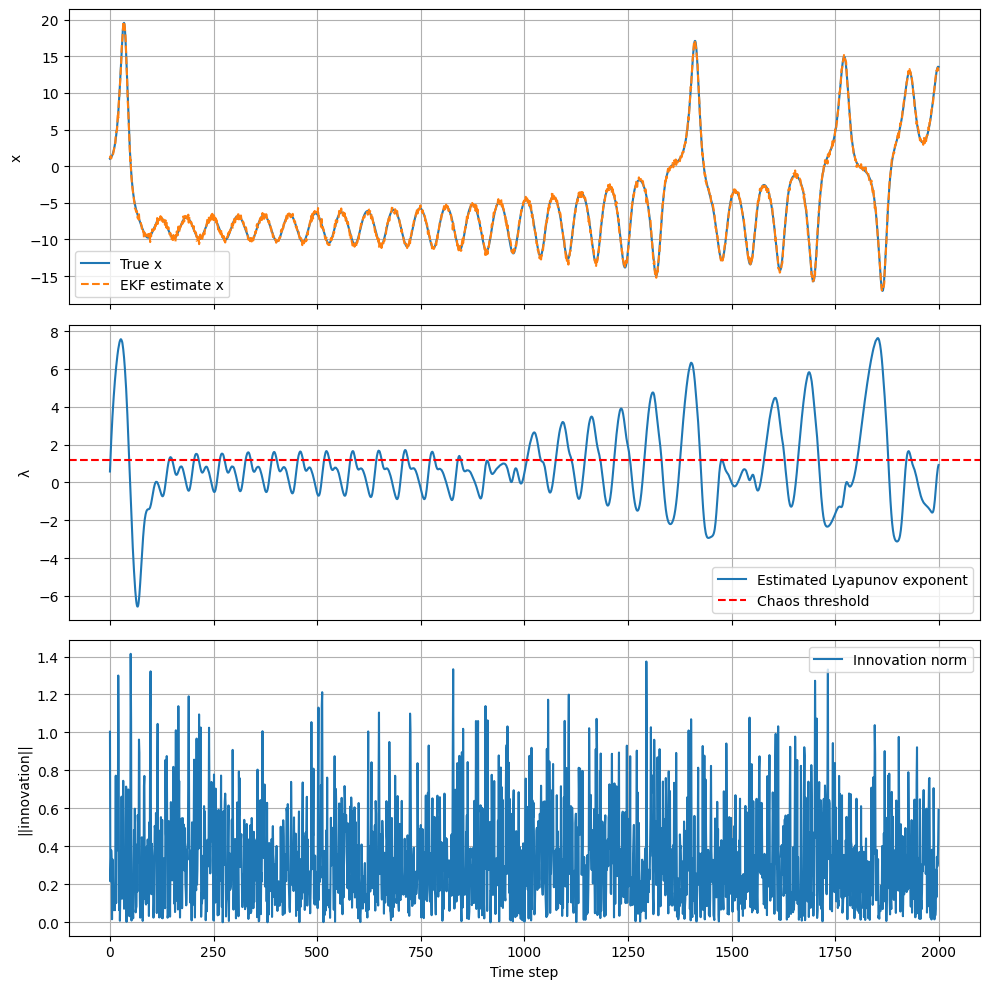

In [1]:

# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# ------------------------------------------------------------
# 1. Lorenz system and Jacobian
# ------------------------------------------------------------
def lorenz_deriv(state, t, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x*(rho - z) - y
    dz = x*y - beta*z
    return np.array([dx, dy, dz])

def lorenz_step(state, dt):
    t = np.array([0, dt])
    sol = odeint(lorenz_deriv, state, t)
    return sol[1]

def lorenz_jacobian(state):
    x, y, z = state
    sigma, rho, beta = 10.0, 28.0, 8.0/3.0
    J = np.array([
        [-sigma, sigma, 0],
        [rho - z, -1, -x],
        [y, x, -beta]
    ])
    return J

# ------------------------------------------------------------
# 2. EKF predict and update
# ------------------------------------------------------------
def ekf_predict(x, P, dt, Q):
    x_pred = lorenz_step(x, dt)
    F = np.eye(3) + lorenz_jacobian(x) * dt
    P_pred = F @ P @ F.T + Q
    return x_pred, P_pred

def ekf_update(x_pred, P_pred, z, H, R):
    y = z - H @ x_pred
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)
    x_upd = x_pred + K @ y
    P_upd = (np.eye(3) - K @ H) @ P_pred
    return x_upd, P_upd, y, K

# ------------------------------------------------------------
# 3. Lyapunov estimation
# ------------------------------------------------------------
def update_lyapunov(delta, F, dt, lambda_avg, alpha=0.95):
    delta_new = F @ delta
    norm_old = np.linalg.norm(delta)
    norm_new = np.linalg.norm(delta_new)
    if norm_old < 1e-12:
        lambda_inst = 0.0
    else:
        lambda_inst = (1.0/dt) * np.log(norm_new / norm_old)
    lambda_avg = alpha * lambda_avg + (1 - alpha) * lambda_inst
    if norm_new > 1e-12:
        delta_new = delta_new / norm_new
    return delta_new, lambda_avg, lambda_inst

# ------------------------------------------------------------
# 4. Slow Q adaptation
# ------------------------------------------------------------
def adapt_Q(Q_base, lambda_avg, lambda_thr=1.2, beta=0.5):
    if lambda_avg > lambda_thr:
        factor = np.exp(beta * (lambda_avg - lambda_thr))
        factor = min(factor, 10.0)
        return Q_base * factor
    return Q_base

# ------------------------------------------------------------
# 5. Safe memory with soft recovery
# ------------------------------------------------------------
class SafeMemory:
    def __init__(self, safe_state, max_size=30, max_age_steps=100):
        self.safe_state = safe_state.copy()
        self.buffer = []
        self.max_size = max_size
        self.max_age = max_age_steps

    def add(self, state, innov, step):
        if innov < 0.5:
            self.buffer.append((state.copy(), innov, step))
            self.buffer = [(s, i, st) for (s, i, st) in self.buffer if step - st < self.max_age]
            if len(self.buffer) > self.max_size:
                self.buffer.pop(0)

    def recover(self, current_state, current_innov, chaos_detected, innov_high_thr=2.0, blend_factor=0.2):
        if chaos_detected and current_innov > innov_high_thr:
            if self.buffer:
                best_state, best_innov, _ = max(self.buffer, key=lambda x: x[2])
                new_state = (1 - blend_factor) * current_state + blend_factor * best_state
                print(f"🔄 Blend with recent good state (innov={best_innov:.3f})")
            else:
                new_state = (1 - blend_factor) * current_state + blend_factor * self.safe_state
                print(f"🔄 Blend with safe state (no recent good)")
            return new_state
        return current_state

# ------------------------------------------------------------
# 6. Simulation parameters (tuned for slow chaos dilation)
# ------------------------------------------------------------
dt = 0.01
T = 20.0
n_steps = int(T / dt)

# True initial state
x0_true = np.array([1.0, 1.0, 1.0])
# Safe state (zero point) – initial guess
x_safe = np.array([2.0, 2.0, 2.0])

# EKF initial estimate
x_est = x_safe.copy()
P = np.eye(3) * 5.0

# Noise covariances
Q_base = np.diag([0.5, 0.5, 0.5])
R = np.array([[0.1]])
H = np.array([[1.0, 0.0, 0.0]])

# Lyapunov parameters
lambda_avg = 0.0
lambda_thr = 1.2        # higher than max Lyapunov (~0.9) -> rarely trigger
beta_meta = 0.5         # small sensitivity
alpha_lambda = 0.95

# Memory
memory = SafeMemory(safe_state=x_safe, max_size=30, max_age_steps=100)

# Storage
true_traj = []
est_traj = []
innovs = []
lyaps = []
q_factors = []

# Generate true trajectory and noisy measurements
true_state = x0_true
measurements = []
for i in range(n_steps):
    true_state = lorenz_step(true_state, dt)
    true_traj.append(true_state)
    z = true_state[0] + np.random.randn() * np.sqrt(R[0,0])
    measurements.append(z)

# Run EKF
state = x_est.copy()
P_state = P
delta_pert = np.random.randn(3) * 1e-6

for i, z in enumerate(measurements):
    F_jac = np.eye(3) + lorenz_jacobian(state) * dt
    delta_pert, lambda_avg, lambda_inst = update_lyapunov(delta_pert, F_jac, dt, lambda_avg, alpha_lambda)
    lyaps.append(lambda_avg)

    Q_adapt = adapt_Q(Q_base, lambda_avg, lambda_thr, beta_meta)
    q_factors.append(np.linalg.norm(Q_adapt) / np.linalg.norm(Q_base))

    state_pred, P_pred = ekf_predict(state, P_state, dt, Q_adapt)
    state_upd, P_upd, y, K = ekf_update(state_pred, P_pred, z, H, R)
    innov = np.linalg.norm(y)
    innovs.append(innov)

    memory.add(state_upd, innov, i)
    chaos_flag = (lambda_avg > lambda_thr)
    state_upd = memory.recover(state_upd, innov, chaos_flag, innov_high_thr=2.0, blend_factor=0.2)
    if chaos_flag:
        P_upd = P_upd * 1.1

    state = state_upd
    P_state = P_upd
    est_traj.append(state)

true_traj = np.array(true_traj)
est_traj = np.array(est_traj)

# ------------------------------------------------------------
# 7. Plot results
# ------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axes[0].plot(true_traj[:,0], label='True x')
axes[0].plot(est_traj[:,0], '--', label='EKF estimate x')
axes[0].set_ylabel('x')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(lyaps, label='Estimated Lyapunov exponent')
axes[1].axhline(lambda_thr, color='r', linestyle='--', label='Chaos threshold')
axes[1].set_ylabel('λ')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(innovs, label='Innovation norm')
axes[2].set_ylabel('||innovation||')
axes[2].set_xlabel('Time step')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()